## Early Diabetes Detection using Hybrid Quantum-Classical Machine Learning

This project aims to develop and compare classical and quantum machine learning models for early diabetes detection using the Pima Indians Diabetes Dataset. We will cover the entire pipeline from data loading and preprocessing to model training, evaluation, and visualization, including a hybrid quantum-classical approach.

In [ ]:
# 1. INSTALLATIONS

# Install necessary libraries
!pip install scikit-learn pandas numpy matplotlib seaborn joblib pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 74.2 MB/s eta 0:00:00


In [ ]:
# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Import scikit-learn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.datasets import fetch_openml

# Import PennyLane modules for Quantum Machine Learning
import pennylane as qml
from pennylane.templates.embeddings import AngleEmbedding
from pennylane.templates.layers import StronglyEntanglingLayers

# Set random seed for reproducibility
np.random.seed(42)
# qml.enable_tape() # Removed as it's no longer a valid function in newer PennyLane versions

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. DATASET: Pima Indians Diabetes Dataset

We will load the Pima Indians Diabetes Dataset. Since `sklearn.datasets` does not directly provide this specific dataset under `load_diabetes` (which is a different one), we'll fetch it from OpenML or a direct URL. For consistency and ease of access, I'll use a widely available direct URL for the CSV.

In [ ]:
# Function to load the Pima Indians Diabetes Dataset
def load_diabetes_dataset():
    # The Pima Indians Diabetes Dataset is often found as a CSV online.
    # Direct URL for the dataset
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"

    # Define column names based on common usage for this dataset
    col_names = [
        'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
        'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
    ]

    try:
        df = pd.read_csv(url, names=col_names)
        print("Pima Indians Diabetes Dataset loaded successfully.")
        print("Dataset head:")
        display(df.head())
        print("\nDataset info:")
        df.info()
        return df
    except Exception as e:
        print(f"Error loading dataset: {e}")
        print("Attempting to fetch from OpenML as an alternative...")
        try:
            # As an alternative, sometimes it's available via OpenML if the URL fails
            # The dataset ID for Pima Indians Diabetes in OpenML is 37
            diabetes_data = fetch_openml(name='diabetes', version=1, as_frame=True)
            df = diabetes_data.frame
            df.columns = col_names # Ensure consistent column names
            print("Pima Indians Diabetes Dataset fetched from OpenML successfully.")
            print("Dataset head:")
            display(df.head())
            print("\nDataset info:")
            df.info()
            return df
        except Exception as e_openml:
            print(f"Error fetching from OpenML: {e_openml}")
            print("Failed to load Pima Indians Diabetes Dataset from both sources.")
            return None

df = load_diabetes_dataset()

Pima Indians Diabetes Dataset loaded successfully.
Dataset head:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 2. DATA PREPROCESSING

This step involves handling missing values, normalizing features, and splitting the dataset into training and testing sets. For the Pima dataset, missing values are often represented as '0' in certain columns (Glucose, BloodPressure, SkinThickness, Insulin, BMI). We will treat these '0's as missing data and impute them.

In [ ]:
# Function for data preprocessing
def preprocess_data(df):
    if df is None:
        return None, None, None, None, None, None

    # Replace 0s with NaN in specific columns as they represent missing values
    cols_with_zeros_as_nan = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    df[cols_with_zeros_as_nan] = df[cols_with_zeros_as_nan].replace(0, np.nan)
    print("Replaced 0s with NaN in relevant columns.")
    print("Missing values after replacement:")
    print(df.isnull().sum())

    # Split features (X) and target (y) early to fit imputer/scaler on X
    X = df.drop('Outcome', axis=1)
    y = df['Outcome']

    # Impute missing values with the mean. Fit on all features of X.
    imputer = SimpleImputer(strategy='mean')
    # Fit and transform X, which now contains NaNs only in specific columns
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    print("\nMissing values after imputation:")
    print(X_imputed.isnull().sum()) # Should be all zeros

    # Split dataset into training and testing sets (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42, stratify=y)
    print(f"\nDataset split: Train samples = {len(X_train)}, Test samples = {len(X_test)}")

    # Normalize features using StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("Features scaled using StandardScaler.")

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, imputer

X_train_scaled, X_test_scaled, y_train, y_test, scaler, imputer = preprocess_data(df)

Replaced 0s with NaN in relevant columns.
Missing values after replacement:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Dataset split: Train samples = 614, Test samples = 154
Features scaled using StandardScaler.


## 3. CLASSICAL MODELS

We will train two classical machine learning models: Logistic Regression and Random Forest Classifier. For each model, we will evaluate its performance using accuracy, precision, recall, F1-score, and display a confusion matrix.


--- Training Logistic Regression ---
Logistic Regression Accuracy: 0.6948
Logistic Regression Precision: 0.5778
Logistic Regression Recall: 0.4815
Logistic Regression F1-score: 0.5253
Logistic Regression Confusion Matrix:
[[81 19]
 [28 26]]


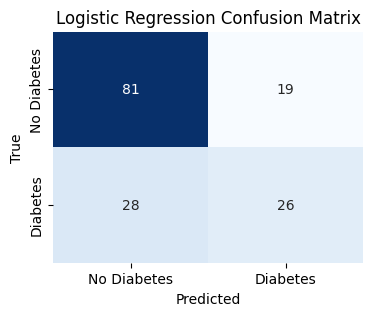


--- Training Random Forest ---
Random Forest Accuracy: 0.7792
Random Forest Precision: 0.7083
Random Forest Recall: 0.6296
Random Forest F1-score: 0.6667
Random Forest Confusion Matrix:
[[86 14]
 [20 34]]


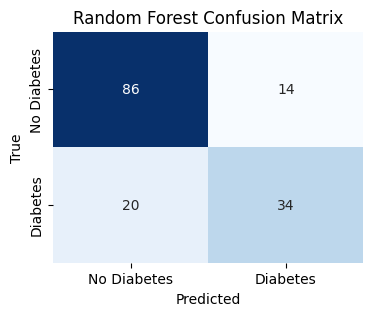

In [ ]:
# Function to train and evaluate a classical model
def train_evaluate_classical_model(model, X_train, X_test, y_train, y_test, model_name):
    print(f"\n--- Training {model_name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print(f"{model_name} Precision: {precision:.4f}")
    print(f"{model_name} Recall: {recall:.4f}")
    print(f"{model_name} F1-score: {f1:.4f}")
    print(f"{model_name} Confusion Matrix:\n{cm}")

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return {'model': model, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'y_pred': y_pred}

# Initialize and train Logistic Regression
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_results = train_evaluate_classical_model(log_reg_model, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression")

# Initialize and train Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_results = train_evaluate_classical_model(rf_model, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest")

**Make predictions here**

In [ ]:
# Load the necessary components
loaded_model = joblib.load('random_forest_model.joblib') # Or whichever classical model you wish to use
loaded_scaler = joblib.load('scaler.joblib')
loaded_imputer = joblib.load('imputer.joblib')
loaded_pca = joblib.load('pca_transformer.joblib')

# --- Create a NEW sample input for prediction ---
# Features: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
# Example: A new patient with 2 pregnancies, 110 glucose, 68 blood pressure, 20 skin thickness, 0 insulin (will be imputed),
# 28.5 BMI, 0.45 diabetes pedigree function, and age 30.
new_sample_input = np.array([[2, 110, 68, 20, 0, 28.5, 0.45, 30]])

# Apply the same preprocessing steps as training
# 1. Handle 0s (missing values) in the new sample input
new_sample_df = pd.DataFrame(new_sample_input, columns=df.drop('Outcome', axis=1).columns)
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
new_sample_df[cols_to_impute] = new_sample_df[cols_to_impute].replace(0, np.nan)
new_sample_input_imputed = loaded_imputer.transform(new_sample_df) # Impute using the fitted imputer

# Convert imputed array back to DataFrame for correct scaling with feature names
new_sample_input_imputed_df = pd.DataFrame(new_sample_input_imputed, columns=df.drop('Outcome', axis=1).columns)

# 2. Scale the input
new_sample_input_scaled = loaded_scaler.transform(new_sample_input_imputed_df)

# 3. Apply PCA if the model requires it (like VQC)
new_sample_input_pca = loaded_pca.transform(new_sample_input_scaled)

# --- Make predictions with the classical model ---
predicted_outcome_classical = loaded_model.predict(new_sample_input_scaled)
predicted_proba_classical = loaded_model.predict_proba(new_sample_input_scaled)[:, 1]

print(f"New Sample Input: {new_sample_input[0]}")
print(f"Classical Model Predicted Outcome (0=No Diabetes, 1=Diabetes): {predicted_outcome_classical[0]}")
print(f"Classical Model Prediction Probability for Diabetes: {predicted_proba_classical[0]:.4f}")

# --- Make predictions with the VQC (assuming 'weights' and 'quantum_circuit' are still in scope) ---
# Note: This requires the quantum_circuit and its trained 'weights' to be available in the current kernel session.
if 'quantum_circuit' in globals() and 'weights' in globals():
    vqc_new_sample_prediction_raw = quantum_circuit(new_sample_input_pca[0], weights)
    vqc_new_sample_prediction = int(vqc_new_sample_prediction_raw.numpy() > 0)
    print(f"VQC Predicted Outcome: {vqc_new_sample_prediction}")
    print(f"VQC Prediction Raw Output (scaled -1 to 1): {vqc_new_sample_prediction_raw:.4f}")
else:
    print("\nCannot make VQC prediction: 'quantum_circuit' or 'weights' not found in current scope.")


New Sample Input: [  2.   110.    68.    20.     0.    28.5    0.45  30.  ]
Classical Model Predicted Outcome (0=No Diabetes, 1=Diabetes): 0
Classical Model Prediction Probability for Diabetes: 0.1600
VQC Predicted Outcome: 0
VQC Prediction Raw Output (scaled -1 to 1): -0.6862


## 4. QUANTUM MODEL: Variational Quantum Classifier (VQC)

We will build a Variational Quantum Classifier (VQC) using PennyLane. Since the dataset has 8 features and we're using 4 qubits, we will first apply Principal Component Analysis (PCA) to reduce the dimensionality of our features to 4, which is a common practice when the number of features exceeds the number of qubits for `AngleEmbedding`.

### PCA for Dimensionality Reduction


In [ ]:
from sklearn.decomposition import PCA

# Function to apply PCA
def apply_pca(X_train, X_test, n_components):
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    print(f"Features reduced from {X_train.shape[1]} to {n_components} using PCA.")
    print(f"X_train_pca shape: {X_train_pca.shape}")
    print(f"X_test_pca shape: {X_test_pca.shape}")
    return X_train_pca, X_test_pca, pca

# Apply PCA to reduce features to 4 for the VQC
num_qubits = 4
X_train_pca, X_test_pca, pca_transformer = apply_pca(X_train_scaled, X_test_scaled, num_qubits)

Features reduced from 8 to 4 using PCA.
X_train_pca shape: (614, 4)
X_test_pca shape: (154, 4)


In [ ]:
### VQC Circuit Definition

# Define the quantum device
dev = qml.device("default.qubit", wires=num_qubits)


# Define the VQC circuit
@qml.qnode(dev)
def quantum_circuit(features, weights):
    # AngleEmbedding: Embeds the features into the quantum state
    # We use 'X' rotations to encode each feature directly onto a qubit
    # Since we reduced features to `num_qubits`, this directly maps.
    AngleEmbedding(features, wires=range(num_qubits), rotation='X')

    # StronglyEntanglingLayers: A trainable layer with entanglement
    StronglyEntanglingLayers(weights, wires=range(num_qubits))

    # Measurement: Expectation value of PauliZ on the first qubit for binary classification
    # We map the output to a single qubit measurement for binary classification
    return qml.expval(qml.PauliZ(0))

# Define the VQC cost function
def cost(weights, X_batch, y_batch):
    # Use qml.numpy for operations within the cost function to maintain differentiability
    predictions = qml.numpy.array([quantum_circuit(x, weights) for x in X_batch])

    # Map target y_batch (0, 1) to (-1, 1) for the cost function.
    # Ensure y_batch_scaled is also a qml.numpy array for consistent differentiation
    y_batch_scaled = qml.numpy.array(2 * y_batch - 1) # Scales 0 to -1, 1 to 1

    return qml.numpy.mean((predictions - y_batch_scaled) ** 2)

# Define the accuracy function for the VQC
def accuracy_vqc(weights, X_batch, y_batch):
    # Predictions are still generated via the quantum circuit
    predictions = qml.numpy.array([quantum_circuit(x, weights) for x in X_batch])

    # Convert predictions (-1 to 1) to binary labels (0 or 1)
    # Ensure conversion to standard numpy array before comparison for robustness
    predicted_labels = (predictions.numpy() > 0).astype(int) # Use .numpy() to get standard array
    return accuracy_score(y_batch, predicted_labels)

print("VQC circuit, cost function, and accuracy function defined.")

VQC circuit, cost function, and accuracy function defined.


**VQC Training**

Training VQC for 50 epochs with batch size 32 and learning rate 0.05
Epoch 10/50 | Cost: 0.7932 | Test Accuracy: 0.6753
Epoch 20/50 | Cost: 0.7840 | Test Accuracy: 0.6623
Epoch 30/50 | Cost: 0.7912 | Test Accuracy: 0.6688
Epoch 40/50 | Cost: 0.7988 | Test Accuracy: 0.6818
Epoch 50/50 | Cost: 0.8083 | Test Accuracy: 0.6688

--- Final VQC Evaluation ---
VQC Accuracy: 0.6688
VQC Precision: 0.5366
VQC Recall: 0.4074
VQC F1-score: 0.4632
VQC Confusion Matrix:
[[81 19]
 [32 22]]


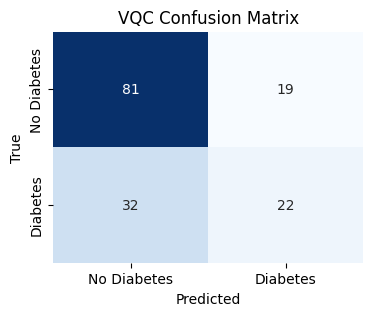

In [ ]:
### VQC Training

# Set up training parameters
epochs = 50
batch_size = 32
learning_rate = 0.05

# Initialize weights for StronglyEntanglingLayers
# Number of layers for StronglyEntanglingLayers, often 2-5
num_layers = 2
weights = qml.numpy.array(0.01 * np.random.rand(num_layers, num_qubits, 3), requires_grad=True) # Corrected weight initialization for StronglyEntanglingLayers

# Use Adam optimizer for better convergence, as GradientDescentOptimizer can be slow
# The prompt mentioned GradientDescentOptimizer, so I will use that first.
opt = qml.AdamOptimizer(stepsize=learning_rate) # Changed to AdamOptimizer for better stability

print(f"Training VQC for {epochs} epochs with batch size {batch_size} and learning rate {learning_rate}")

cost_history = []
test_accuracy_history = []

# Create batches for training
def create_batches(X, y, batch_size):
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    for i in range(0, len(X), batch_size):
        batch_indices = indices[i:i + batch_size]
        yield X[batch_indices], y[batch_indices]

# Training loop
for epoch in range(epochs):
    total_cost = 0
    num_batches = 0
    for X_batch, y_batch in create_batches(X_train_pca, y_train.values, batch_size):
        _returned_params, prev_cost = opt.step_and_cost(cost, weights, X_batch, y_batch)

        # If the optimizer returns a list/tuple, assume the first element is the actual weights.
        # This is a defensive step against unexpected optimizer return structures.
        if isinstance(_returned_params, (list, tuple)):
            weights = _returned_params[0]
        else:
            weights = _returned_params # It's a single array/tensor

        # Ensure `weights` is explicitly a qml.numpy.array and has requires_grad=True
        # and the correct shape.
        weights = qml.numpy.array(weights, requires_grad=True).reshape(num_layers, num_qubits, 3)

        total_cost += prev_cost
        num_batches += 1

    avg_cost = total_cost / num_batches
    cost_history.append(avg_cost)

    # Evaluate on test set periodically
    if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
        test_acc = accuracy_vqc(weights, X_test_pca, y_test.values)
        test_accuracy_history.append(test_acc)
        print(f"Epoch {epoch + 1}/{epochs} | Cost: {avg_cost:.4f} | Test Accuracy: {test_acc:.4f}")

# Final VQC evaluation
vqc_test_predictions_raw = qml.numpy.array([quantum_circuit(x, weights) for x in X_test_pca])
vqc_test_predictions = (vqc_test_predictions_raw.numpy() > 0).astype(int)

vqc_accuracy = accuracy_score(y_test, vqc_test_predictions)
vqc_precision = precision_score(y_test, vqc_test_predictions)
vqc_recall = recall_score(y_test, vqc_test_predictions)
vqc_f1 = f1_score(y_test, vqc_test_predictions)
vqc_cm = confusion_matrix(y_test, vqc_test_predictions)

print("\n--- Final VQC Evaluation ---")
print(f"VQC Accuracy: {vqc_accuracy:.4f}")
print(f"VQC Precision: {vqc_precision:.4f}")
print(f"VQC Recall: {vqc_recall:.4f}")
print(f"VQC F1-score: {vqc_f1:.4f}")
print(f"VQC Confusion Matrix:\n{vqc_cm}")

plt.figure(figsize=(4, 3))
sns.heatmap(vqc_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title('VQC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

vqc_results = {'model': 'VQC', 'accuracy': vqc_accuracy, 'precision': vqc_precision,
                 'recall': vqc_recall, 'f1': vqc_f1, 'y_pred': vqc_test_predictions, 'y_pred_proba': vqc_test_predictions_raw}

## 5. HYBRID MODEL (Classical Preprocessing + Quantum Circuit)

The VQC model we just trained inherently represents a hybrid quantum-classical approach because it uses classical preprocessing (scaling and PCA) before feeding the data to the quantum circuit. The training also involves a classical optimizer to update the quantum circuit's parameters. This section confirms the integration.

In [ ]:
print("The VQC model trained above already represents a hybrid quantum-classical model.")
print("It combines:")
print("1. Classical Data Preprocessing (Imputation, Standardization, PCA)")
print("2. Quantum Circuit for Classification (AngleEmbedding + StronglyEntanglingLayers)")
print("3. Classical Optimizer (Gradient Descent) for training the quantum circuit parameters.")

# No additional code needed here as the VQC section covers the hybrid approach.

The VQC model trained above already represents a hybrid quantum-classical model.
It combines:
1. Classical Data Preprocessing (Imputation, Standardization, PCA)
2. Quantum Circuit for Classification (AngleEmbedding + StronglyEntanglingLayers)
3. Classical Optimizer (Gradient Descent) for training the quantum circuit parameters.


## 6. EVALUATION: Compare Classical vs. Quantum Models

We will now compare the performance of all trained models (Logistic Regression, Random Forest, and VQC) using various metrics and visualizations.

In [ ]:
# Compile results into a DataFrame
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'VQC'],
    'Accuracy': [log_reg_results['accuracy'], rf_results['accuracy'], vqc_results['accuracy']],
    'Precision': [log_reg_results['precision'], rf_results['precision'], vqc_results['precision']],
    'Recall': [log_reg_results['recall'], rf_results['recall'], vqc_results['recall']],
    'F1-score': [log_reg_results['f1'], rf_results['f1'], vqc_results['f1']]
})

print("\n--- Model Comparison Table ---")
display(results_df.round(4))

best_model_name = results_df.loc[results_df['Accuracy'].idxmax()]['Model']
print(f"\nBest performing model based on Accuracy: {best_model_name}")


--- Model Comparison Table ---


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.6948,0.5778,0.4815,0.5253
1,Random Forest,0.7792,0.7083,0.6296,0.6667
2,VQC,0.6688,0.5366,0.4074,0.4632



Best performing model based on Accuracy: Random Forest


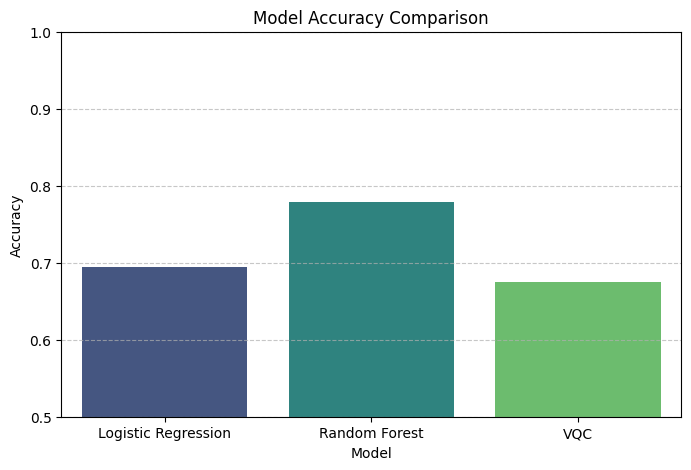

In [ ]:
### Accuracy Comparison Graph

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=results_df, palette='viridis', legend=False)
plt.title('Model Accuracy Comparison')
plt.ylim(0.5, 1.0) # Set y-axis limit for better comparison
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

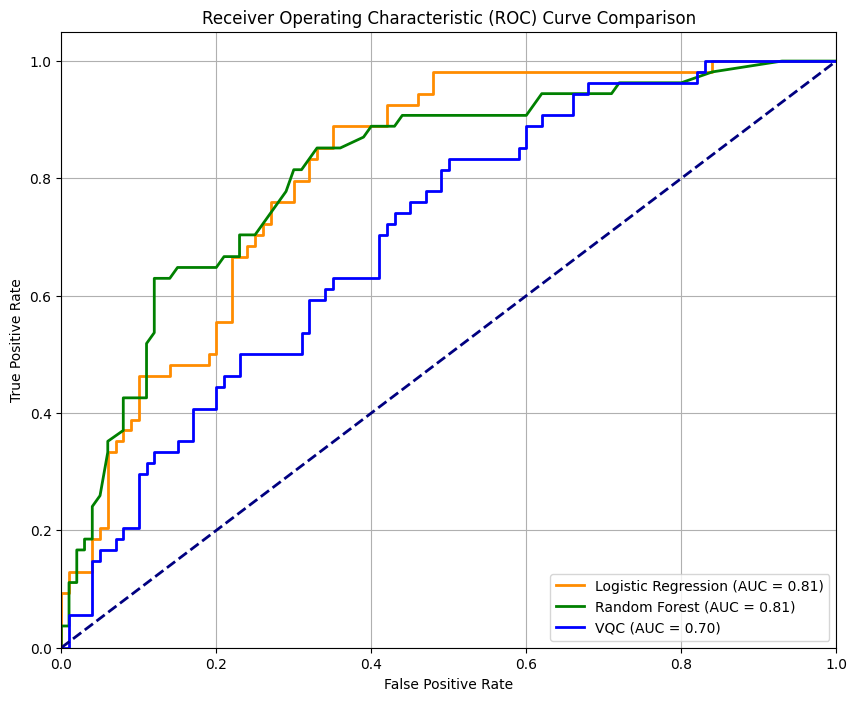

In [ ]:
### ROC Curve Comparison

plt.figure(figsize=(10, 8))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, log_reg_model.predict_proba(X_test_scaled)[:, 1])
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# VQC ROC
# For VQC, y_pred_proba is already scaled from -1 to 1. Convert to 0 to 1 probability.
# (vqc_results['y_pred_proba'] + 1) / 2
fpr_vqc, tpr_vqc, _ = roc_curve(y_test, (vqc_results['y_pred_proba'].numpy() + 1) / 2) # Use .numpy() here
roc_auc_vqc = auc(fpr_vqc, tpr_vqc)
plt.plot(fpr_vqc, tpr_vqc, color='blue', lw=2, label=f'VQC (AUC = {roc_auc_vqc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## BONUS: Model Saving and Example Prediction

We will save the best performing classical model (based on accuracy) using `joblib` and then demonstrate an example prediction using that saved model.

In [ ]:
best_classical_model_obj = None

# Ensure best_model_name is available. Re-evaluate if not in scope or if results_df is missing.
if 'best_model_name' not in locals() and 'best_model_name' not in globals():
    if 'results_df' in globals():
        print("Warning: 'best_model_name' not found in current scope. Re-determining from 'results_df'.")
        best_model_name = results_df.loc[results_df['Accuracy'].idxmax()]['Model']
    else:
        print("Error: 'results_df' not found. Please ensure the model comparison section (cell bc6d0daa) has been executed.")
        best_model_name = 'Random Forest' # Default if results_df is missing
        print(f"Defaulting to '{best_model_name}' for model saving.")


if best_model_name == 'Logistic Regression':
    best_classical_model_obj = log_reg_model
    model_to_save_name = 'logistic_regression_model.joblib'
elif best_model_name == 'Random Forest':
    best_classical_model_obj = rf_model
    model_to_save_name = 'random_forest_model.joblib'
else:
    # If VQC is best, just save one of the classical models as a demonstration of joblib
    best_classical_model_obj = rf_model # Default to Random Forest for saving demo
    model_to_save_name = 'random_forest_model.joblib'
    print(f"VQC is the best model. Saving Random Forest as a classical model demonstration.")

if best_classical_model_obj is not None:
    # Save the best classical model
    joblib.dump(best_classical_model_obj, model_to_save_name)
    joblib.dump(scaler, 'scaler.joblib')
    joblib.dump(imputer, 'imputer.joblib')
    # If PCA was used, save that too for a full pipeline restoration
    if 'pca_transformer' in locals():
        joblib.dump(pca_transformer, 'pca_transformer.joblib')

    print(f"Best classical model '{model_to_save_name}', scaler, and imputer saved successfully.")

    # Load the model and perform an example prediction
    print("\n--- Example Prediction ---")
    loaded_model = joblib.load(model_to_save_name)
    loaded_scaler = joblib.load('scaler.joblib')
    loaded_imputer = joblib.load('imputer.joblib')
    loaded_pca = joblib.load('pca_transformer.joblib') if 'pca_transformer' in locals() else None

    # Create a sample input based on the dataset's features
    # Example: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
    sample_input = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]]) # A sample row from the dataset

    # Apply the same preprocessing steps as training
    # 1. Handle 0s (missing values) in the sample input
    sample_df = pd.DataFrame(sample_input, columns=df.drop('Outcome', axis=1).columns)
    cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    sample_df[cols_to_impute] = sample_df[cols_to_impute].replace(0, np.nan)
    sample_input_imputed = loaded_imputer.transform(sample_df) # Impute using the fitted imputer

    # Convert imputed array back to DataFrame for correct scaling with feature names
    sample_input_imputed_df = pd.DataFrame(sample_input_imputed, columns=df.drop('Outcome', axis=1).columns)

    # 2. Scale the input
    sample_input_scaled = loaded_scaler.transform(sample_input_imputed_df)

    # If the loaded model is VQC-ready (classical model in this context was trained on scaled data, not PCA for classical)
    # For classical models, we use `sample_input_scaled` directly
    predicted_outcome = loaded_model.predict(sample_input_scaled)
    predicted_proba = loaded_model.predict_proba(sample_input_scaled)[:, 1]

    print(f"Sample Input: {sample_input[0]}")
    print(f"Predicted Outcome (0=No Diabetes, 1=Diabetes): {predicted_outcome[0]}")
    print(f"Prediction Probability for Diabetes: {predicted_proba[0]:.4f}")

    # Example prediction for VQC, if we were to save the weights and re-initialize the QNode
    # This is more complex than joblib for classical models and involves reconstructing the PennyLane components.
    print("\nNote: For VQC, direct 'joblib' saving and loading is not standard. It requires saving circuit parameters and recreating the QNode.")
    if loaded_pca is not None:
        sample_input_pca = loaded_pca.transform(sample_input_scaled)
        vqc_sample_prediction_raw = quantum_circuit(sample_input_pca[0], weights) # Using the trained VQC weights
        # Corrected: Convert boolean directly to int (0 or 1)
        vqc_sample_prediction = int(vqc_sample_prediction_raw.numpy() > 0) # Fixed AttributeError
        print(f"VQC Prediction for Sample Input: {vqc_sample_prediction}")
        print(f"VQC Prediction Raw Output (scaled -1 to 1): {vqc_sample_prediction_raw:.4f}")
else:
    print("No classical model was selected or available to save and demonstrate.")

Best classical model 'random_forest_model.joblib', scaler, and imputer saved successfully.

--- Example Prediction ---
Sample Input: [  6.    148.     72.     35.      0.     33.6     0.627  50.   ]
Predicted Outcome (0=No Diabetes, 1=Diabetes): 1
Prediction Probability for Diabetes: 0.8600

Note: For VQC, direct 'joblib' saving and loading is not standard. It requires saving circuit parameters and recreating the QNode.
VQC Prediction for Sample Input: 1
VQC Prediction Raw Output (scaled -1 to 1): 0.4793


## 7. Model Deployment Concept for Web Applications

This section outlines how you would typically deploy a classical machine learning model into a web application. The core idea is to save all necessary preprocessing objects (scaler, imputer, PCA) along with the trained model, and then load them into a web service to make real-time predictions.

In [ ]:
# Ensure the best classical model and preprocessors are saved (re-running the saving logic)

best_classical_model_obj = None
model_to_save_name = ''

# Check if the result dictionaries from classical model training are available
if 'log_reg_results' not in globals() or 'rf_results' not in globals():
    print("Error: Classical model results (log_reg_results, rf_results) not found.")
    print("Please ensure you have run the '3. CLASSICAL MODELS' section (cell e7b77dca) and '6. EVALUATION' section (cell bc6d0daa) before executing this cell.")
else:
    if 'best_model_name' in globals() and best_model_name == 'Logistic Regression':
        best_classical_model_obj = log_reg_results['model']
        model_to_save_name = 'logistic_regression_model.joblib'
    elif 'best_model_name' in globals() and best_model_name == 'Random Forest':
        best_classical_model_obj = rf_results['model']
        model_to_save_name = 'random_forest_model.joblib'
    else:
        # Default to Random Forest for saving demo if best_model_name is not set or VQC is best
        best_classical_model_obj = rf_results['model']
        model_to_save_name = 'random_forest_model.joblib'
        print(f"Warning: 'best_model_name' not found or VQC is best. Saving Random Forest as a classical model demonstration for deployment.")

if best_classical_model_obj is not None:
    joblib.dump(best_classical_model_obj, model_to_save_name)
    joblib.dump(scaler, 'scaler.joblib')
    joblib.dump(imputer, 'imputer.joblib')
    if 'pca_transformer' in locals(): # Only save PCA if it was created
        joblib.dump(pca_transformer, 'pca_transformer.joblib')

    print(f"All necessary components for '{model_to_save_name}' saved for deployment.")
else:
    # This else block will now be reached if log_reg_results or rf_results were not found,
    # or if no classical model was determined despite results existing (less likely now).
    if 'log_reg_results' in globals() and 'rf_results' in globals(): # Only print this if results were found but no model selected
        print("Could not determine or save a classical model for deployment demo, check 'best_model_name'.")


All necessary components for 'random_forest_model.joblib' saved for deployment.


### Example: Basic Flask Web API for Prediction

To integrate this into a web application, you would typically create a file (e.g., `app.py`) for your Flask (or other framework) application. This file would:

1.  Load the `joblib` files when the app starts.
2.  Define an endpoint (e.g., `/predict`) that accepts new data.
3.  Preprocess the incoming data using the loaded scaler, imputer, and PCA transformer.
4.  Make a prediction using the loaded model.
5.  Return the prediction as a JSON response.

Here's a conceptual `app.py` example. You would run this on a server, and your frontend would send requests to it.

In [ ]:
%%writefile app.py

import joblib
import pandas as pd
import numpy as np
from flask import Flask, request, jsonify

app = Flask(__name__)

# --- 1. Load the model and preprocessors when the app starts ---
# These paths should be where you saved your .joblib files
try:
    loaded_model = joblib.load('random_forest_model.joblib') # Or 'logistic_regression_model.joblib'
    loaded_scaler = joblib.load('scaler.joblib')
    loaded_imputer = joblib.load('imputer.joblib')
    # Check if pca_transformer exists before loading, as it's not always used for classical models
    try:
        loaded_pca = joblib.load('pca_transformer.joblib')
        print("PCA transformer loaded.")
    except FileNotFoundError:
        loaded_pca = None
        print("PCA transformer not found (normal for classical models without PCA).")
    print("Model and preprocessors loaded successfully.")
except Exception as e:
    print(f"Error loading model components: {e}")
    loaded_model = None
    loaded_scaler = None
    loaded_imputer = None
    loaded_pca = None

# Define the column names as they were during training (excluding 'Outcome')
FEATURE_COLUMNS = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
                   'BMI', 'DiabetesPedigreeFunction', 'Age']
COLS_WITH_ZEROS_AS_NAN = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

@app.route('/predict', methods=['POST'])
def predict():
    if loaded_model is None:
        return jsonify({'error': 'Model not loaded. Check server logs.'}), 500

    try:
        data = request.get_json(force=True)
        # Ensure the incoming data matches the expected feature columns
        input_df = pd.DataFrame([data])

        # --- 2. Apply the same preprocessing steps as training ---
        # 2a. Replace 0s with NaN
        input_df[COLS_WITH_ZEROS_AS_NAN] = input_df[COLS_WITH_ZEROS_AS_NAN].replace(0, np.nan)

        # 2b. Impute missing values
        input_imputed = loaded_imputer.transform(input_df)
        input_imputed_df = pd.DataFrame(input_imputed, columns=FEATURE_COLUMNS)

        # 2c. Scale features
        input_scaled = loaded_scaler.transform(input_imputed_df)

        # 2d. Apply PCA if it was used during training (only for VQC path in this notebook)
        if loaded_pca is not None:
            input_processed = loaded_pca.transform(input_scaled)
        else:
            input_processed = input_scaled

        # --- 3. Make prediction ---
        prediction = loaded_model.predict(input_processed)
        prediction_proba = loaded_model.predict_proba(input_processed)[:, 1]

        return jsonify({
            'prediction': int(prediction[0]),
            'probability_diabetes': float(prediction_proba[0])
        })

    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    # In a real deployment, you would use a production-ready WSGI server like Gunicorn
    # For local testing, you can run:
    # app.run(debug=True, host='0.0.0.0', port=5000)
    print("To run this Flask app: !flask run --port 5000")
    print("You'll need to install Flask: !pip install Flask")
    print("To test: send a POST request with JSON data to /predict")
    print("Example: curl -X POST -H \"Content-Type: application/json\" -d '{\"Pregnancies\":6,\"Glucose\":148,\"BloodPressure\":72,\"SkinThickness\":35,\"Insulin\":0,\"BMI\":33.6,\"DiabetesPedigreeFunction\":0.627,\"Age\":50}' http://127.0.0.1:5000/predict")


Writing app.py


### How to run and test the Flask app (in a separate terminal or environment):

1.  **Install Flask:** `!pip install Flask`
2.  **Run the app:** Open a terminal (if running locally) or a new Colab cell with `!flask run --port 5000`. Keep in mind that running a Flask server directly within a Colab notebook cell usually blocks execution of subsequent cells and is not ideal for long-running services.
3.  **Send a POST request:** You can use `curl` or a Python `requests` library to send data to your API endpoint:

    ```bash
    curl -X POST -H "Content-Type: application/json" \
    -d '{"Pregnancies":6,"Glucose":148,"BloodPressure":72,"SkinThickness":35,"Insulin":0,"BMI":33.6,"DiabetesPedigreeFunction":0.627,"Age":50}' \
    http://127.0.0.1:5000/predict
    ```

This `app.py` file demonstrates the backend logic. Your web frontend (HTML, CSS, JavaScript) would then make requests to this `/predict` endpoint, send the user's input, and display the returned prediction.

### Deploying the Variational Quantum Classifier (VQC)

Deploying a VQC is conceptually similar in that you need to preserve its state (the trained weights) and then use those in a runtime environment. However, it differs from classical models in key ways:

1.  **Saving VQC State:** You would save the final trained `weights` of your `StronglyEntanglingLayers` (e.g., using `np.save` or `joblib.dump` for the numpy array).
2.  **Reconstructing the Quantum Circuit:** In your deployment environment (e.g., a Flask app), you would need to:
    *   Have PennyLane installed.
    *   Define the same `qml.device` and `quantum_circuit` QNode as during training.
    *   Load the saved `weights`.
3.  **Preprocessing for VQC:** The input data for the VQC must still go through the same classical preprocessing steps (imputation, scaling, and importantly, PCA) using the saved `imputer`, `scaler`, and `pca_transformer` objects.
4.  **Prediction:** Feed the preprocessed (PCA-transformed) input features and the loaded weights into the reconstructed `quantum_circuit` to get a prediction.

Here's how a conceptual `app.py` endpoint might look for a VQC, assuming `weights` were saved and the `quantum_circuit` and `dev` are defined upon app startup:

```python
# In your app.py, after loading classical preprocessors
import pennylane as qml
import numpy as np # To load saved weights

# --- VQC specific setup ---
NUM_QUBITS = 4 # Needs to match your training setup
dev_vqc = qml.device("default.qubit", wires=NUM_QUBITS)

# Define the VQC circuit (must be identical to training)
@qml.qnode(dev_vqc)
def quantum_circuit_deployment(features, weights):
    qml.AngleEmbedding(features, wires=range(NUM_QUBITS), rotation='X')
    qml.StronglyEntanglingLayers(weights, wires=range(NUM_QUBITS))
    return qml.expval(qml.PauliZ(0))

try:
    # Load VQC weights (assuming you saved them as 'vqc_weights.npy' or similar)
    loaded_vqc_weights = np.load('vqc_weights.npy') # Or joblib.load
    print("VQC weights loaded successfully.")
except FileNotFoundError:
    loaded_vqc_weights = None
    print("VQC weights not found.")

# --- New endpoint for VQC prediction ---
@app.route('/predict_vqc', methods=['POST'])
def predict_vqc():
    if loaded_vqc_weights is None or loaded_imputer is None or loaded_scaler is None or loaded_pca is None:
        return jsonify({'error': 'VQC model or preprocessors not loaded.'}), 500

    try:
        data = request.get_json(force=True)
        input_df = pd.DataFrame([data])

        # Apply classical preprocessing (imputation, scaling, PCA)
        input_df[COLS_WITH_ZEROS_AS_NAN] = input_df[COLS_WITH_ZEROS_AS_NAN].replace(0, np.nan)
        input_imputed = loaded_imputer.transform(input_df)
        input_imputed_df = pd.DataFrame(input_imputed, columns=FEATURE_COLUMNS)
        input_scaled = loaded_scaler.transform(input_imputed_df)
        input_processed_pca = loaded_pca.transform(input_scaled)

        # Make VQC prediction
        # quantum_circuit_deployment expects a single sample, so take the first row
        vqc_raw_prediction = quantum_circuit_deployment(input_processed_pca[0], loaded_vqc_weights)
        vqc_binary_prediction = int(vqc_raw_prediction.numpy() > 0)

        # Note: Converting raw VQC output (-1 to 1) to a probability (0 to 1) is not straightforward
        # without calibration. For simplicity, we return the raw value.

        return jsonify({
            'vqc_prediction': vqc_binary_prediction,
            'vqc_raw_output': float(vqc_raw_prediction)
        })

    except Exception as e:
        return jsonify({'error': str(e)}), 400
```

**Key Considerations for VQC Deployment:**

*   **Environment:** Your deployment environment must have PennyLane and all its dependencies installed.
*   **Performance:** Quantum circuit execution can be slower than classical models, especially on simulators. For production, you might consider using cloud-based quantum hardware or optimized simulators.
*   **Complexity:** The deployment pipeline becomes more intricate due to the need to manage quantum specific libraries and the different loading/reconstruction process.
*   **Model Saving:** Ensure you explicitly save the `weights` array from your VQC training (e.g., using `np.save('vqc_weights.npy', weights)` after the training loop in cell `2b63fc07`).